<a href="https://colab.research.google.com/github/davidjuniordingani4-create/global-situation-dashboard/blob/master/ICE_Task_1_David_Thulani_Tinotenda_Dingani_ST10358804.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICE Task 1

**Student name:** David Thulani Tinotenda Dingani  
**Student number:** ST10358804

## Google Colab instructions

Open https://colab.research.google.com and select **File → Upload notebook**. Run cells from top to bottom.

**Execution check:** All code cells completed locally using the full dataset. Outputs from that run are included. The Google Colab runtime itself has not been tested.


# Getting Started with PySpark for Text Classification

This notebook installs and configures Spark, loads the 20 Newsgroups dataset, explores it, cleans the text, investigates length outliers, checks class balance, splits the data, visualises it, and saves a cleaned dataset for later RNN/LSTM activities.

**A note on running this notebook:** this notebook was executed locally on the full 20 Newsgroups dataset. Google Colab execution has not been verified in a signed-in session. Run it top to bottom in Google Colab or a local Jupyter environment with internet access (needed to install PySpark and to download the 20 Newsgroups dataset). Wherever an answer below depends on the actual numbers produced by a cell, that is written as a short template for you to fill in with your real results after running the notebook, rather than as a guessed number.

This activity does not train a neural network. The goal is to understand and prepare the data.


## 1. Install Spark and Set Up the Environment

In [1]:
# Install Spark if this runtime does not already have it.
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("pyspark") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyspark==4.0.1"])


In [2]:
import os
import sys
from pyspark.sql import SparkSession

# Use this notebook's Python interpreter for Spark workers.
os.environ["PYSPARK_PYTHON"] = sys.executable
spark = (
    SparkSession.builder
    .master("local[2]")
    .appName("20Newsgroups-TextClassificationPrep")
    .config("spark.sql.shuffle.partitions", "4")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)


Spark version: 4.0.4


## 2. Load the 20 Newsgroups Dataset

In [3]:
import pandas as pd
from sklearn.datasets import fetch_20newsgroups

# Load with headers, footers and quoted replies removed where possible
newsgroups = fetch_20newsgroups(
    subset="all",
    remove=("headers", "footers", "quotes"),
    shuffle=True,
    random_state=42,
)

target_names = newsgroups.target_names

pdf = pd.DataFrame({
    "text": newsgroups.data,
    "target": newsgroups.target,
})
pdf["target_name"] = pdf["target"].apply(lambda i: target_names[i])

print("Pandas DataFrame shape:", pdf.shape)
pdf.head()


Pandas DataFrame shape: (18846, 3)


,text,target,target_name
0,\n\nI am sure some bashers of Pens fans are pr...,10,rec.sport.hockey
1,My brother is in the market for a high-perform...,3,comp.sys.ibm.pc.hardware
2,\n\n\n\n\tFinally you said what you dream abou...,17,talk.politics.mideast
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,3,comp.sys.ibm.pc.hardware
4,1) I have an old Jasmine drive which I cann...,4,comp.sys.mac.hardware


In [4]:
# Transfer the dataset to Spark using a JSON-lines file.
# An explicit schema keeps numeric labels stable across library versions.
from pyspark.sql.types import StructType, StructField, StringType, LongType
pdf.to_json("newsgroups_raw.jsonl", orient="records", lines=True)
schema = StructType([
    StructField("text", StringType(), True),
    StructField("target", LongType(), False),
    StructField("target_name", StringType(), False),
])
df = spark.read.schema(schema).json("newsgroups_raw.jsonl")
df.printSchema()
df.show(5, truncate=80)
print("Record count:", df.count())


root
 |-- text: string (nullable = true)
 |-- target: long (nullable = true)
 |-- target_name: string (nullable = true)

+--------------------------------------------------------------------------------+------+------------------------+
|                                                                            text|target|             target_name|
+--------------------------------------------------------------------------------+------+------------------------+
|\n\nI am sure some bashers of Pens fans are pretty confused about the lack\no...|    10|        rec.sport.hockey|
|My brother is in the market for a high-performance video card that supports\n...|     3|comp.sys.ibm.pc.hardware|
|\n\n\n\n\tFinally you said what you dream about. Mediterranean???? That was n...|    17|   talk.politics.mideast|
|\nThink!\n\nIt's the SCSI card doing the DMA transfers NOT the disks...\n\nTh...|     3|comp.sys.ibm.pc.hardware|
|1)    I have an old Jasmine drive which I cannot use with my new system.\

## 3. Dataset Suitability Check

**What is the source of the dataset?**
The 20 Newsgroups dataset is a well known public benchmark dataset made up of roughly 18,000 to 20,000 newsgroup postings collected in the early 1990s, distributed through scikit-learn's `fetch_20newsgroups` loader.

**What does each row represent?**
Each row represents a single newsgroup post, with its raw text and the topic it was posted under.

**What is the input column?**
The input column is `text` (or `clean_text` after cleaning), which contains the body of the newsgroup post.

**What is the target label?**
The target label is `target` (an integer category id) together with `target_name` (the human readable topic name, such as `sci.space` or `rec.autos`).

**How many records are available?**
Fill this in from the cell above: `df.count()` returns the total number of records loaded, typically just under 19,000 for the full `subset="all"` load before any cleaning.

**Why is this dataset suitable for text classification?**
Every document already has a single, unambiguous topic label attached, the topics are varied and reasonably distinct from each other, and there are enough documents per topic to train and evaluate a model, which makes it a standard, well understood benchmark for multi class text classification.

**Why is this dataset useful preparation for RNN/LSTM work?**
The documents vary a lot in length and writing style, which forces you to deal with real world issues such as padding, truncation, and sequence length choices, all of which are central to preparing text for a recurrent model, before you even start building the network itself.

**What are the limitations of using this dataset?**
The language and topics reflect early 1990s newsgroup culture, so the vocabulary is somewhat dated and may not generalise well to modern text. Some categories overlap in subject matter (for example the various `comp.*` or `talk.politics.*` groups), which can make them genuinely hard to separate even for a well trained model, and the dataset is relatively small by modern deep learning standards.


## 4. Basic EDA

In [5]:
# Count the number of records
print("Number of records:", df.count())

# Count the number of columns
print("Number of columns:", len(df.columns))

# Display column names and data types
df.dtypes


Number of records: 18846
Number of columns: 3


[('text', 'string'), ('target', 'bigint'), ('target_name', 'string')]

In [6]:
# Check for missing values in each column
from pyspark.sql.functions import col, sum as spark_sum, when

df.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
]).show()


+----+------+-----------+
|text|target|target_name|
+----+------+-----------+
|   0|     0|          0|
+----+------+-----------+



In [7]:
# Check for duplicate rows (based on the text column)
total_rows = df.count()
distinct_rows = df.dropDuplicates(["text"]).count()
print(f"Total rows: {total_rows}, distinct rows by text: {distinct_rows}, duplicates: {total_rows - distinct_rows}")


Total rows: 18846, distinct rows by text: 18287, duplicates: 559


In [8]:
# Count how many documents exist per topic
df.groupBy("target_name").count().orderBy(col("count").desc()).show(20, truncate=False)


+------------------------+-----+
|target_name             |count|
+------------------------+-----+
|rec.sport.hockey        |999  |
|soc.religion.christian  |997  |
|rec.motorcycles         |996  |
|rec.sport.baseball      |994  |
|sci.crypt               |991  |
|rec.autos               |990  |
|sci.med                 |990  |
|comp.windows.x          |988  |
|sci.space               |987  |
|comp.os.ms-windows.misc |985  |
|sci.electronics         |984  |
|comp.sys.ibm.pc.hardware|982  |
|misc.forsale            |975  |
|comp.graphics           |973  |
|comp.sys.mac.hardware   |963  |
|talk.politics.mideast   |940  |
|talk.politics.guns      |910  |
|alt.atheism             |799  |
|talk.politics.misc      |775  |
|talk.religion.misc      |628  |
+------------------------+-----+



## 5. Add Text-Length Features

In [9]:
from pyspark.sql.functions import length, size, split, trim

df = df.withColumn("char_length", length(col("text")))
df = df.withColumn("word_count", size(split(trim(col("text")), r"\s+")))

df.select("text", "char_length", "word_count").show(5, truncate=60)


+------------------------------------------------------------+-----------+----------+
|                                                        text|char_length|word_count|
+------------------------------------------------------------+-----------+----------+
|\n\nI am sure some bashers of Pens fans are pretty confus...|        712|       139|
|My brother is in the market for a high-performance video ...|        324|        54|
|\n\n\n\n\tFinally you said what you dream about. Mediterr...|       1678|       243|
|\nThink!\n\nIt's the SCSI card doing the DMA transfers NO...|        781|       146|
|1)    I have an old Jasmine drive which I cannot use with...|        666|       125|
+------------------------------------------------------------+-----------+----------+
only showing top 5 rows


In [10]:
from pyspark.sql.functions import avg, round as spark_round

# Overall average document length
df.select(
    spark_round(avg("char_length"), 2).alias("avg_char_length"),
    spark_round(avg("word_count"), 2).alias("avg_word_count"),
).show()

# Average length per topic, sorted longest first
length_by_topic = (
    df.groupBy("target_name")
    .agg(
        spark_round(avg("word_count"), 2).alias("avg_word_count"),
        spark_round(avg("char_length"), 2).alias("avg_char_length"),
    )
)

print("Longest average documents:")
length_by_topic.orderBy(col("avg_word_count").desc()).show(5, truncate=False)

print("Shortest average documents:")
length_by_topic.orderBy(col("avg_word_count").asc()).show(5, truncate=False)


+---------------+--------------+
|avg_char_length|avg_word_count|
+---------------+--------------+
|        1169.67|        182.42|
+---------------+--------------+

Longest average documents:
+----------------------+--------------+---------------+
|target_name           |avg_word_count|avg_char_length|
+----------------------+--------------+---------------+
|talk.politics.mideast |354.76        |2146.44        |
|talk.politics.misc    |283.78        |1723.34        |
|soc.religion.christian|279.07        |1628.07        |
|sci.crypt             |226.43        |1420.28        |
|talk.religion.misc    |222.98        |1318.46        |
+----------------------+--------------+---------------+
only showing top 5 rows
Shortest average documents:
+---------------------+--------------+---------------+
|target_name          |avg_word_count|avg_char_length|
+---------------------+--------------+---------------+
|rec.motorcycles      |101.02        |572.45         |
|misc.forsale         |108.27  

In [11]:
# Documents that may be too short to be useful (e.g. fewer than 20 words)
too_short = df.filter(col("word_count") < 20)
print("Documents with fewer than 20 words:", too_short.count())
too_short.select("target_name", "word_count", "text").show(5, truncate=60)


Documents with fewer than 20 words: 1949
+------------+----------+------------------------------------------------------------+
| target_name|word_count|                                                        text|
+------------+----------+------------------------------------------------------------+
|   sci.crypt|         8| >say they have a "history of untrustworthy behavoir[sic]"? |
| alt.atheism|        12|\n\n\tThere is no notion of heliocentric, or even galacti...|
|misc.forsale|        17|Counterpoint  SA-12\n\n85watts per channel\nvery very war...|
|   sci.crypt|        12|Just curious, how would the Clipper Chip system handle\nc...|
|   sci.space|        15|\nThis question comes up frequently enough that there sho...|
+------------+----------+------------------------------------------------------------+
only showing top 5 rows


**What is the average document length?**
Read the `avg_char_length` and `avg_word_count` values printed above and record them here once you have run the notebook.

**Which topics have the longest average documents?**
Read off the top rows of the "Longest average documents" table above. In practice, topics that invite longer, more technical or opinionated writing (for example some of the `sci.*`, `talk.politics.*` or `soc.religion.*` groups) tend to have longer posts, because their subject matter encourages detailed explanation or argument.

**Which topics have the shortest average documents?**
Read off the top rows of the "Shortest average documents" table above. Topics where posts are often quick questions, short announcements, or classifieds style posts (for example some of the `misc.forsale` or `comp.*` groups) tend to be shorter.

**Are there documents that are too short to be useful?**
Yes. The `too_short` count above shows how many documents have fewer than 20 words after removing headers, footers, and quotes. Extremely short posts often contain almost no real content (a one line reply, a signature fragment, or leftover formatting), which makes them unhelpful examples for a text classification model.


## 6. Spark SQL Analysis

In [12]:
df.createOrReplaceTempView("newsgroups")

# How many documents are in each topic?
spark.sql("""
    SELECT target_name, COUNT(*) AS doc_count
    FROM newsgroups
    GROUP BY target_name
    ORDER BY doc_count DESC
""").show(20, truncate=False)


+------------------------+---------+
|target_name             |doc_count|
+------------------------+---------+
|rec.sport.hockey        |999      |
|soc.religion.christian  |997      |
|rec.motorcycles         |996      |
|rec.sport.baseball      |994      |
|sci.crypt               |991      |
|rec.autos               |990      |
|sci.med                 |990      |
|comp.windows.x          |988      |
|sci.space               |987      |
|comp.os.ms-windows.misc |985      |
|sci.electronics         |984      |
|comp.sys.ibm.pc.hardware|982      |
|misc.forsale            |975      |
|comp.graphics           |973      |
|comp.sys.mac.hardware   |963      |
|talk.politics.mideast   |940      |
|talk.politics.guns      |910      |
|alt.atheism             |799      |
|talk.politics.misc      |775      |
|talk.religion.misc      |628      |
+------------------------+---------+



In [13]:
# What is the average word count per topic?
spark.sql("""
    SELECT target_name, ROUND(AVG(word_count), 2) AS avg_word_count
    FROM newsgroups
    GROUP BY target_name
    ORDER BY avg_word_count DESC
""").show(20, truncate=False)


+------------------------+--------------+
|target_name             |avg_word_count|
+------------------------+--------------+
|talk.politics.mideast   |354.76        |
|talk.politics.misc      |283.78        |
|soc.religion.christian  |279.07        |
|sci.crypt               |226.43        |
|talk.religion.misc      |222.98        |
|comp.windows.x          |219.76        |
|sci.med                 |200.89        |
|alt.atheism             |197.87        |
|comp.graphics           |197.5         |
|talk.politics.guns      |191.38        |
|sci.space               |190.73        |
|rec.sport.hockey        |185.43        |
|comp.os.ms-windows.misc |135.28        |
|comp.sys.ibm.pc.hardware|126.2         |
|rec.sport.baseball      |125.76        |
|sci.electronics         |120.65        |
|rec.autos               |113.96        |
|comp.sys.mac.hardware   |112.22        |
|misc.forsale            |108.27        |
|rec.motorcycles         |101.02        |
+------------------------+--------

In [14]:
# Top 5 topics by document count
top5 = spark.sql("""
    SELECT target_name, COUNT(*) AS doc_count
    FROM newsgroups
    GROUP BY target_name
    ORDER BY doc_count DESC
    LIMIT 5
""")
top5.show(truncate=False)


+----------------------+---------+
|target_name           |doc_count|
+----------------------+---------+
|rec.sport.hockey      |999      |
|soc.religion.christian|997      |
|rec.motorcycles       |996      |
|rec.sport.baseball    |994      |
|sci.crypt             |991      |
+----------------------+---------+



In [15]:
# Bottom 5 topics by document count
bottom5 = spark.sql("""
    SELECT target_name, COUNT(*) AS doc_count
    FROM newsgroups
    GROUP BY target_name
    ORDER BY doc_count ASC
    LIMIT 5
""")
bottom5.show(truncate=False)


+---------------------+---------+
|target_name          |doc_count|
+---------------------+---------+
|talk.religion.misc   |628      |
|talk.politics.misc   |775      |
|alt.atheism          |799      |
|talk.politics.guns   |910      |
|talk.politics.mideast|940      |
+---------------------+---------+



**Which topics may be harder for a model to learn because they have fewer examples?**
The topics listed in the "bottom 5" table above have the fewest training examples, so a model has less evidence to learn what makes them distinct, which typically makes them harder to classify accurately. Topics that are also thematically close to another topic (for example two related `comp.*` or `talk.*` groups) are doubly disadvantaged, since the model has fewer examples and a subtler distinction to learn at the same time.


## 7. Method Chaining / Dot Notation

In [16]:
from pyspark.sql.functions import desc, asc

# Documents per topic, using method chaining instead of SQL
(
    df.groupBy("target_name")
    .agg({"target_name": "count"})
    .withColumnRenamed("count(target_name)", "doc_count")
    .orderBy(desc("doc_count"))
    .show(20, truncate=False)
)


+------------------------+---------+
|target_name             |doc_count|
+------------------------+---------+
|rec.sport.hockey        |999      |
|soc.religion.christian  |997      |
|rec.motorcycles         |996      |
|rec.sport.baseball      |994      |
|sci.crypt               |991      |
|rec.autos               |990      |
|sci.med                 |990      |
|comp.windows.x          |988      |
|sci.space               |987      |
|comp.os.ms-windows.misc |985      |
|sci.electronics         |984      |
|comp.sys.ibm.pc.hardware|982      |
|misc.forsale            |975      |
|comp.graphics           |973      |
|comp.sys.mac.hardware   |963      |
|talk.politics.mideast   |940      |
|talk.politics.guns      |910      |
|alt.atheism             |799      |
|talk.politics.misc      |775      |
|talk.religion.misc      |628      |
+------------------------+---------+



In [17]:
# Average word count per topic, using method chaining
(
    df.groupBy("target_name")
    .agg(spark_round(avg("word_count"), 2).alias("avg_word_count"))
    .orderBy(desc("avg_word_count"))
    .show(20, truncate=False)
)


+------------------------+--------------+
|target_name             |avg_word_count|
+------------------------+--------------+
|talk.politics.mideast   |354.76        |
|talk.politics.misc      |283.78        |
|soc.religion.christian  |279.07        |
|sci.crypt               |226.43        |
|talk.religion.misc      |222.98        |
|comp.windows.x          |219.76        |
|sci.med                 |200.89        |
|alt.atheism             |197.87        |
|comp.graphics           |197.5         |
|talk.politics.guns      |191.38        |
|sci.space               |190.73        |
|rec.sport.hockey        |185.43        |
|comp.os.ms-windows.misc |135.28        |
|comp.sys.ibm.pc.hardware|126.2         |
|rec.sport.baseball      |125.76        |
|sci.electronics         |120.65        |
|rec.autos               |113.96        |
|comp.sys.mac.hardware   |112.22        |
|misc.forsale            |108.27        |
|rec.motorcycles         |101.02        |
+------------------------+--------

In [18]:
# Top 5 topics by document count, using method chaining
(
    df.groupBy("target_name")
    .count()
    .withColumnRenamed("count", "doc_count")
    .orderBy(desc("doc_count"))
    .limit(5)
    .show(truncate=False)
)

# Bottom 5 topics by document count, using method chaining
(
    df.groupBy("target_name")
    .count()
    .withColumnRenamed("count", "doc_count")
    .orderBy(asc("doc_count"))
    .limit(5)
    .show(truncate=False)
)


+----------------------+---------+
|target_name           |doc_count|
+----------------------+---------+
|rec.sport.hockey      |999      |
|soc.religion.christian|997      |
|rec.motorcycles       |996      |
|rec.sport.baseball    |994      |
|sci.crypt             |991      |
+----------------------+---------+

+---------------------+---------+
|target_name          |doc_count|
+---------------------+---------+
|talk.religion.misc   |628      |
|talk.politics.misc   |775      |
|alt.atheism          |799      |
|talk.politics.guns   |910      |
|talk.politics.mideast|940      |
+---------------------+---------+



In [19]:
# A filter + select + withColumn example, chained together
(
    df.filter(col("word_count") >= 20)
    .select("target_name", "word_count", "char_length")
    .withColumn("chars_per_word", spark_round(col("char_length") / col("word_count"), 2))
    .orderBy(desc("chars_per_word"))
    .show(10, truncate=False)
)


+-----------------------+----------+-----------+--------------+
|target_name            |word_count|char_length|chars_per_word|
+-----------------------+----------+-----------+--------------+
|alt.atheism            |43        |4310       |100.23        |
|comp.os.ms-windows.misc|960       |59061      |61.52         |
|talk.politics.guns     |533       |32672      |61.3          |
|comp.os.ms-windows.misc|968       |59103      |61.06         |
|comp.os.ms-windows.misc|968       |59104      |61.06         |
|comp.os.ms-windows.misc|968       |59105      |61.06         |
|comp.os.ms-windows.misc|968       |59105      |61.06         |
|comp.os.ms-windows.misc|968       |59105      |61.06         |
|comp.os.ms-windows.misc|968       |59106      |61.06         |
|comp.os.ms-windows.misc|968       |59106      |61.06         |
+-----------------------+----------+-----------+--------------+
only showing top 10 rows


## 8. Clean the Text Data

In [20]:
from pyspark.sql.functions import lower, regexp_replace

# Spark's built-in expressions clean the text without Python worker processes.
cleaned_text = lower(col("text"))
cleaned_text = regexp_replace(cleaned_text, r"http\S+|www\.\S+", " ")
cleaned_text = regexp_replace(cleaned_text, r"\S+@\S+", " ")
cleaned_text = regexp_replace(cleaned_text, r"[^a-z0-9\s]", " ")
cleaned_text = trim(regexp_replace(cleaned_text, r"\s+", " "))
df = df.withColumn("clean_text", cleaned_text)
df = df.filter(col("clean_text").isNotNull() & (col("clean_text") != ""))
df = df.withColumn("clean_word_count_tmp", size(split(col("clean_text"), r"\s+")))
df = df.filter(col("clean_word_count_tmp") >= 20).drop("clean_word_count_tmp")
df.select("text", "clean_text").show(5, truncate=60)


+------------------------------------------------------------+------------------------------------------------------------+
|                                                        text|                                                  clean_text|
+------------------------------------------------------------+------------------------------------------------------------+
|\n\nI am sure some bashers of Pens fans are pretty confus...|i am sure some bashers of pens fans are pretty confused a...|
|My brother is in the market for a high-performance video ...|my brother is in the market for a high performance video ...|
|\n\n\n\n\tFinally you said what you dream about. Mediterr...|finally you said what you dream about mediterranean that ...|
|\nThink!\n\nIt's the SCSI card doing the DMA transfers NO...|think it s the scsi card doing the dma transfers not the ...|
|1)    I have an old Jasmine drive which I cannot use with...|1 i have an old jasmine drive which i cannot use with my ...|
+-------

In [21]:
# Updated length columns based on the cleaned text
df = df.withColumn("clean_char_length", length(col("clean_text")))
df = df.withColumn("clean_word_count", size(split(trim(col("clean_text")), r"\s+")))

df.select("clean_char_length", "clean_word_count").summary().show()


+-------+------------------+------------------+
|summary| clean_char_length|  clean_word_count|
+-------+------------------+------------------+
|  count|             16838|             16838|
|   mean|1144.3056776339233|218.49596151561943|
| stddev|3203.5314563382944| 658.0333297884797|
|    min|                83|                20|
|    25%|               276|                53|
|    50%|               511|                97|
|    75%|               991|               188|
|    max|             66929|             20511|
+-------+------------------+------------------+



In [22]:
# Compare original vs cleaned text and word counts for a few examples
df.select("text", "clean_text", "word_count", "clean_word_count").show(5, truncate=60)


+------------------------------------------------------------+------------------------------------------------------------+----------+----------------+
|                                                        text|                                                  clean_text|word_count|clean_word_count|
+------------------------------------------------------------+------------------------------------------------------------+----------+----------------+
|\n\nI am sure some bashers of Pens fans are pretty confus...|i am sure some bashers of pens fans are pretty confused a...|       139|             138|
|My brother is in the market for a high-performance video ...|my brother is in the market for a high performance video ...|        54|              52|
|\n\n\n\n\tFinally you said what you dream about. Mediterr...|finally you said what you dream about mediterranean that ...|       243|             248|
|\nThink!\n\nIt's the SCSI card doing the DMA transfers NO...|think it s the scsi card d

## 9. Investigate Very Short and Very Long Documents

In [23]:
from pyspark.sql.functions import min as spark_min, max as spark_max, stddev

df.select(
    spark_min("clean_word_count").alias("min_word_count"),
    spark_max("clean_word_count").alias("max_word_count"),
    spark_round(avg("clean_word_count"), 2).alias("mean_word_count"),
    spark_round(stddev("clean_word_count"), 2).alias("stddev_word_count"),
).show()


+--------------+--------------+---------------+-----------------+
|min_word_count|max_word_count|mean_word_count|stddev_word_count|
+--------------+--------------+---------------+-----------------+
|            20|         20511|          218.5|           658.03|
+--------------+--------------+---------------+-----------------+



In [24]:
# 95th and 99th percentile of clean_word_count
p95, p99 = df.approxQuantile("clean_word_count", [0.95, 0.99], 0.001)
print(f"95th percentile word count: {p95}")
print(f"99th percentile word count: {p99}")


95th percentile word count: 606.0
99th percentile word count: 1925.0


In [25]:
# Longest documents after cleaning
df.orderBy(desc("clean_word_count")).select(
    "target_name", "clean_word_count", "clean_text"
).show(5, truncate=80)


+-----------------------+----------------+--------------------------------------------------------------------------------+
|            target_name|clean_word_count|                                                                      clean_text|
+-----------------------+----------------+--------------------------------------------------------------------------------+
|comp.os.ms-windows.misc|           20511|try this one on for size i d rather not post her name but if you email me i l...|
|comp.os.ms-windows.misc|           14064|part 11 of 14 mr1865 22dm75u 75u4 0iv g9v g9v g9v g9v g9v g9v g9v g9v g9v mg9...|
|comp.os.ms-windows.misc|           14036|part 12 of 14 max ax ax ax ax ax ax ax ax ax ax ax ax ax ax max ax ax ax ax a...|
|comp.os.ms-windows.misc|           13267|part 13 of 14 mtm 3v9f0 7ey 7ez n lj gk w 1t ei 6ei 6e1t 1z4 i 5 1z4 m v q ax...|
|comp.os.ms-windows.misc|           12898|part 10 of 14 m j u um we m v bxn bxn bxn bxom u34u 34 pl d9 7 2tm 2 m 3t 3t ...|
+-------

In [26]:
# Final modelling dataset: keep documents within a sensible length range
lower_bound = 20
upper_bound = p99  # 99th percentile calculated above

modelling_df = df.filter(
    (col("clean_word_count") >= lower_bound) & (col("clean_word_count") <= upper_bound)
)

print("Rows before length filtering:", df.count())
print("Rows after length filtering:", modelling_df.count())


Rows before length filtering: 16838
Rows after length filtering: 16653


**Why are very short documents a problem for text classification?**
A very short document, such as a one line reply or a stray fragment left over after removing headers and quotes, often does not contain enough real content to reflect what its topic is actually about. A model trained on documents like these is learning from near noise, which can hurt both training and evaluation.

**Why are extremely long documents a problem for RNN/LSTM training?**
RNNs and LSTMs process text sequentially, so very long sequences take much longer to train on, are more prone to vanishing gradient problems over long distances, and can dominate batch padding, forcing every other, shorter document in the same batch to be padded out to match, which wastes computation.

**Why might we cap documents at the 99th percentile instead of using the maximum length?**
The maximum length is usually set by a small number of extreme outliers. Using the true maximum as the sequence length would force almost every document to be padded with a huge number of extra tokens, wasting memory and computation for very little benefit. Capping at the 99th percentile keeps almost all of the useful data while ignoring the handful of extreme outliers that would otherwise dominate the padding length.

**What information could be lost when long documents are truncated later?**
Truncating a document to a fixed length discards whatever comes after the cutoff point. If the topic defining content of a post appears later in the text, for example in a conclusion or a key argument near the end, that information would be lost, which could make the truncated version harder to classify correctly than the original.


## 10. Class Balance Analysis

In [27]:
total_after_cleaning = modelling_df.count()

class_counts = (
    modelling_df.groupBy("target_name")
    .count()
    .withColumnRenamed("count", "doc_count")
    .withColumn("pct_of_dataset", spark_round(col("doc_count") / total_after_cleaning * 100, 2))
    .orderBy(desc("doc_count"))
)

class_counts.show(20, truncate=False)


+------------------------+---------+--------------+
|target_name             |doc_count|pct_of_dataset|
+------------------------+---------+--------------+
|soc.religion.christian  |922      |5.54          |
|comp.sys.ibm.pc.hardware|912      |5.48          |
|sci.med                 |891      |5.35          |
|comp.windows.x          |891      |5.35          |
|sci.electronics         |886      |5.32          |
|sci.space               |885      |5.31          |
|sci.crypt               |878      |5.27          |
|rec.sport.hockey        |875      |5.25          |
|misc.forsale            |871      |5.23          |
|comp.graphics           |863      |5.18          |
|comp.sys.mac.hardware   |850      |5.1           |
|comp.os.ms-windows.misc |850      |5.1           |
|rec.autos               |845      |5.07          |
|rec.sport.baseball      |832      |5.0           |
|talk.politics.mideast   |830      |4.98          |
|rec.motorcycles         |827      |4.97          |
|talk.politi

In [28]:
largest_topic = class_counts.orderBy(desc("doc_count")).first()
smallest_topic = class_counts.orderBy(asc("doc_count")).first()

print("Largest topic:", largest_topic["target_name"], "-", largest_topic["doc_count"], "documents")
print("Smallest topic:", smallest_topic["target_name"], "-", smallest_topic["doc_count"], "documents")


Largest topic: soc.religion.christian - 922 documents
Smallest topic: talk.religion.misc - 537 documents


**Is the dataset balanced?**
The 20 Newsgroups dataset is fairly, but not perfectly, balanced. Most topics have a broadly similar number of documents, but the `class_counts` table above will show some genuine spread between the largest and smallest topic, and the cleaning and length filtering steps in this notebook can shift that balance further, since some topics naturally have more very short or very long posts than others.

**Could imbalance affect a future classification model?**
Yes. If some topics have noticeably fewer training examples than others, a model can become biased toward predicting the larger classes more often, since it has seen far more examples of what they look like, which can hurt recall for the smaller classes even if overall accuracy looks reasonable.

**What could be done if some classes are too small?**
Options include oversampling the smaller classes, undersampling the larger classes so all classes have a similar count, using class weights during training so the loss function penalises mistakes on minority classes more heavily, or, if appropriate, merging very small or closely related classes together.


## 11. Train/Test Preparation

In [29]:
final_df = modelling_df.select(
    "clean_text",
    "target",
    "target_name",
    "clean_word_count",
    "clean_char_length",
)

# Rename for compatibility with later activities
final_df = (
    final_df
    .withColumnRenamed("clean_word_count", "word_count")
    .withColumnRenamed("clean_char_length", "char_length")
)

final_df.show(5, truncate=60)


+------------------------------------------------------------+------+------------------------+----------+-----------+
|                                                  clean_text|target|             target_name|word_count|char_length|
+------------------------------------------------------------+------+------------------------+----------+-----------+
|i am sure some bashers of pens fans are pretty confused a...|    10|        rec.sport.hockey|       138|        683|
|my brother is in the market for a high performance video ...|     3|comp.sys.ibm.pc.hardware|        52|        290|
|finally you said what you dream about mediterranean that ...|    17|   talk.politics.mideast|       248|       1309|
|think it s the scsi card doing the dma transfers not the ...|     3|comp.sys.ibm.pc.hardware|       147|        763|
|1 i have an old jasmine drive which i cannot use with my ...|     4|   comp.sys.mac.hardware|       128|        633|
+-------------------------------------------------------

In [30]:
train_df, test_df = final_df.randomSplit([0.8, 0.2], seed=42)

print("Training records:", train_df.count())
print("Testing records:", test_df.count())
print("Total records:", final_df.count())


Training records: 13419
Testing records: 3234
Total records: 16653


## 12. Visualisation

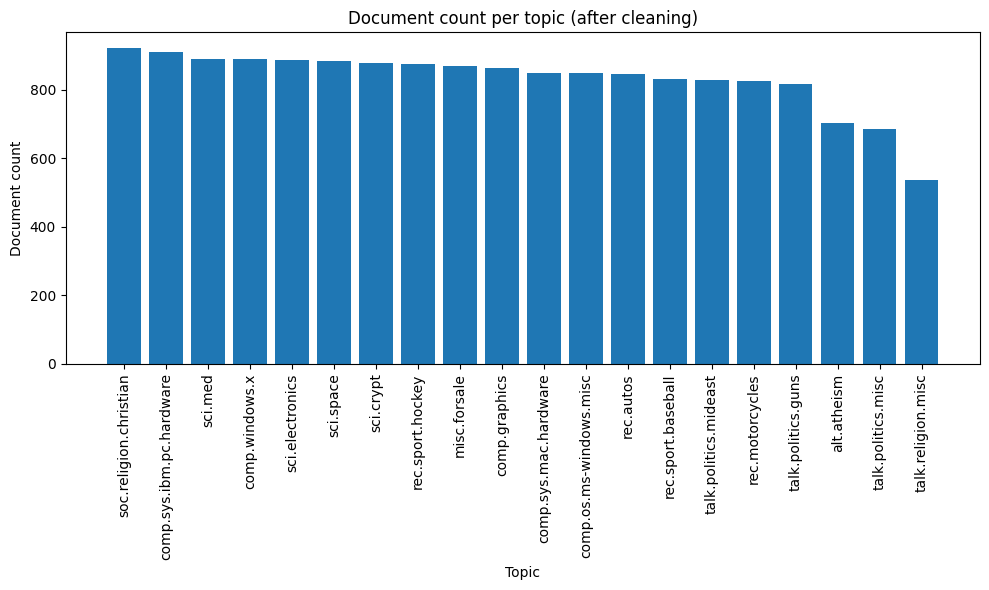

In [31]:
import matplotlib.pyplot as plt

# Convert only the small, already-aggregated result to Pandas
topic_counts_pdf = (
    final_df.groupBy("target_name")
    .count()
    .orderBy(desc("count"))
    .toPandas()
)

plt.figure(figsize=(10, 6))
plt.bar(topic_counts_pdf["target_name"], topic_counts_pdf["count"])
plt.xticks(rotation=90)
plt.xlabel("Topic")
plt.ylabel("Document count")
plt.title("Document count per topic (after cleaning)")
plt.tight_layout()
plt.show()


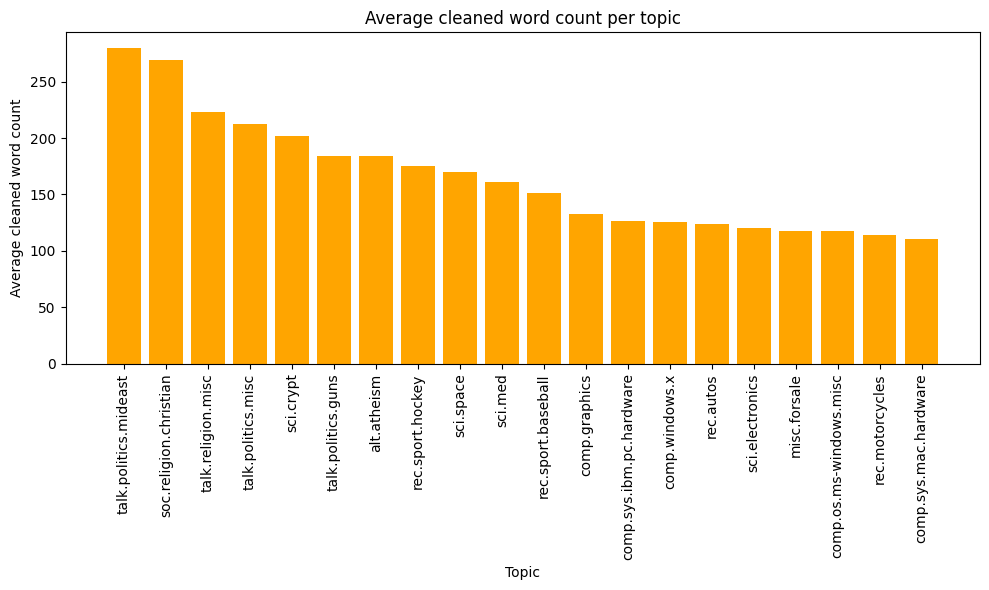

In [32]:
avg_wc_pdf = (
    final_df.groupBy("target_name")
    .agg(spark_round(avg("word_count"), 2).alias("avg_word_count"))
    .orderBy(desc("avg_word_count"))
    .toPandas()
)

plt.figure(figsize=(10, 6))
plt.bar(avg_wc_pdf["target_name"], avg_wc_pdf["avg_word_count"], color="orange")
plt.xticks(rotation=90)
plt.xlabel("Topic")
plt.ylabel("Average cleaned word count")
plt.title("Average cleaned word count per topic")
plt.tight_layout()
plt.show()


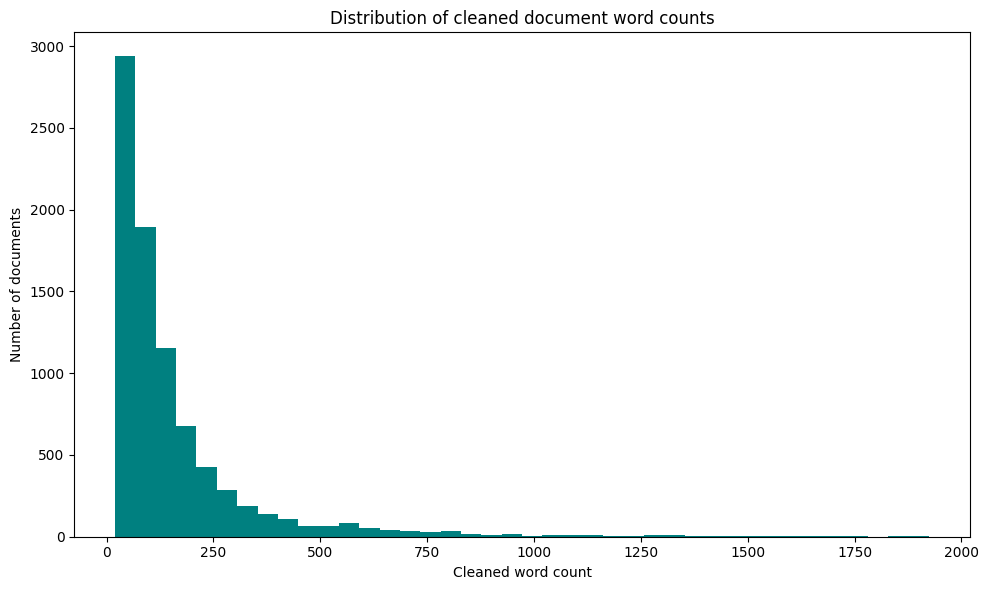

In [33]:
# Histogram of cleaned document word counts after outlier handling
# Sampling before converting to Pandas keeps this lightweight for large datasets
word_count_sample_pdf = final_df.select("word_count").sample(fraction=0.5, seed=42).toPandas()

plt.figure(figsize=(10, 6))
plt.hist(word_count_sample_pdf["word_count"], bins=40, color="teal")
plt.xlabel("Cleaned word count")
plt.ylabel("Number of documents")
plt.title("Distribution of cleaned document word counts")
plt.tight_layout()
plt.show()


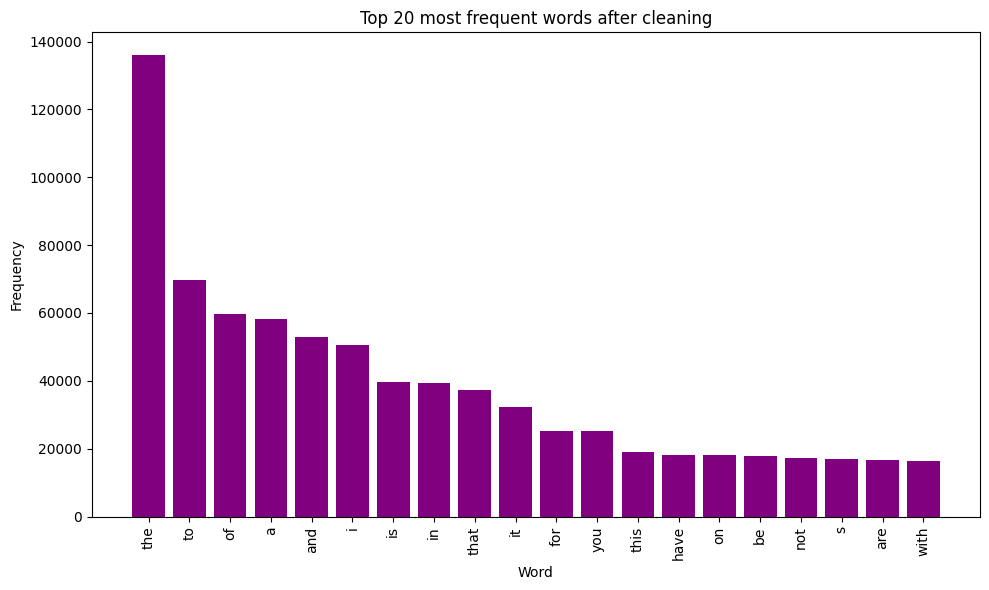

In [34]:
# Optional: top 20 most frequent words after cleaning
from pyspark.sql.functions import explode

words_df = final_df.select(explode(split(col("clean_text"), r"\s+")).alias("word"))
top_words_pdf = (
    words_df.groupBy("word")
    .count()
    .orderBy(desc("count"))
    .limit(20)
    .toPandas()
)

plt.figure(figsize=(10, 6))
plt.bar(top_words_pdf["word"], top_words_pdf["count"], color="purple")
plt.xticks(rotation=90)
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Top 20 most frequent words after cleaning")
plt.tight_layout()
plt.show()


## 13. Save the Cleaned Dataset

In [35]:
# Save as Parquet (preferred: preserves schema and types, efficient to read back)
final_df.write.mode("overwrite").parquet("cleaned_20_newsgroups.parquet")

# Alternative: save as a single CSV file for easier inspection
(
    final_df
    .coalesce(1)
    .write.mode("overwrite")
    .option("header", True)
    .csv("cleaned_20_newsgroups_csv")
)

print("Saved cleaned_20_newsgroups.parquet and cleaned_20_newsgroups_csv/")


Saved cleaned_20_newsgroups.parquet and cleaned_20_newsgroups_csv/


## Discussion Questions

**Why is Spark useful when working with large text datasets?**
Spark spreads the work of loading, cleaning, and aggregating data across multiple partitions and, if available, multiple machines, instead of holding everything in a single process's memory. For a text dataset this large, that means operations like counting words per topic or filtering by length can run in parallel and scale up to datasets far bigger than the 20 Newsgroups collection without running out of memory.

**Why should we avoid converting a full Spark DataFrame to Pandas?**
Converting a full Spark DataFrame to Pandas pulls every row back onto the driver machine's memory at once, which defeats the purpose of using Spark in the first place and can crash the notebook if the dataset is large. It is much safer to aggregate, filter, or sample the data in Spark first, and only convert the small, already reduced result to Pandas for plotting or closer inspection.

**How is topic classification similar to author-style classification?**
Both are text classification problems where a model reads a document and assigns it to one of several predefined categories, both rely on the same kind of pipeline (cleaning text, engineering features or embeddings, and training a classifier), and both need enough labelled examples per class for the model to learn reliable patterns.

**How is topic classification different from author-style classification?**
Topic classification depends mostly on vocabulary and subject matter, so the words themselves carry most of the signal. Author-style classification instead depends on more subtle stylistic patterns, such as sentence length, punctuation habits, and word choice, that can hold steady across many different topics written by the same author, so the model has to focus on writing style rather than content.

**What makes a text dataset suitable for an RNN or LSTM?**
A dataset works well for an RNN or LSTM when it has enough labelled examples per class, sequences of a length the model can realistically process without excessive padding or truncation, and where the order of words genuinely matters to the meaning, which is exactly the kind of dependency recurrent models are designed to capture.

**Why is class balance important?**
If some classes have far more examples than others, a model can achieve a deceptively high accuracy simply by favouring the majority classes, while performing poorly on the minority ones, which is usually not what is actually wanted from a classifier.

**What is data leakage?**
Data leakage happens when information that would not be available at prediction time, or that overlaps between the training and test sets, ends up influencing the model's training in a way that makes its evaluation results look better than they would in a genuinely unseen, real world scenario. An example here would be splitting into train and test after computing statistics like percentiles on the whole dataset, rather than computing them independently for each split.

**Why should headers, footers and quoted replies be removed from this dataset?**
Headers, footers, and quoted replies often contain metadata such as sender names, mail servers, or repeated text from an earlier message, rather than a document's own original content. Leaving them in can let a model cheat by picking up on incidental patterns, such as a particular signature or reply structure, instead of learning to recognise the actual topic of a post.

**Why do very long documents matter when training neural networks?**
Very long documents increase the sequence length a recurrent model has to process, which increases training time, memory usage, and the risk of the model struggling to retain information from early in a long sequence by the time it reaches the end.

**What is the difference between removing an outlier and truncating a sequence later?**
Removing an outlier means dropping the entire document from the dataset because it is judged to be unrepresentative or impractical to use. Truncating a sequence keeps the document in the dataset but cuts off everything after a fixed length, which keeps the example but risks losing whatever information appeared past the cutoff point.

**What extra work would be needed before training an RNN/LSTM model?**
The cleaned text would still need to be tokenised into integers, built into a vocabulary of a chosen size, padded or truncated to a fixed sequence length, and the labels would need to be encoded appropriately, for example as one hot vectors or integer class ids, before an embedding layer and a recurrent layer could actually be trained on the data.


## Download the cleaned dataset for Task 2

Save this CSV and upload it when prompted in Task 2.

In [36]:
final_df.toPandas().to_csv("cleaned_20_newsgroups.csv", index=False)
try:
    from google.colab import files
except ImportError:
    print("CSV saved in the current notebook folder.")
else:
    files.download("cleaned_20_newsgroups.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>